In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.style.use('seaborn-v0_8-paper')
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

from ttcrpy.rgrid import Grid3d

# Example 1 (OpenCL) - Comparing CPU and GPU Fast-Sweeping Method

This example reuses the 3D layered model of example 1 and compares the
regular (CPU) implementation of the Fast-Sweeping Method (FSM) with the
OpenCL implementation that runs on the GPU.

The model contains 10 horizontal layers of homogeneous velocity, with layer
velocity increasing linearly downward.  The rectilinear grid contains
40 x 40 x 40 voxels.

The OpenCL implementation is selected by passing `fsm_gpu=True` together with
`method='FSM'`.  It requires that `ttcrpy` was built with OpenCL support and
that a working OpenCL device is available on the machine.

We use single precision (`dtype=np.float32`) here: many GPUs (in particular
Apple and integrated GPUs) do not support double precision (`cl_khr_fp64`).
When double precision is requested on such a device, the OpenCL grid prints a
warning and transparently falls back to the CPU implementation, so the GPU
would never actually be exercised.

In [2]:
N = 40        # number if voxels in each direction
dx = 0.5      # cell size

# coordinates of the nodes
xn = np.arange(0, (N+1)*dx, dx)
yn = np.arange(0, (N+1)*dx, dx)
zn = np.arange(0, (N+1)*dx, dx)

# values of slowness along vertical axis, define first vertical gradient
a = 1.0
V20 = 3.0
b = (V20-a)/20.0
# fill array
slowness = np.empty((N,))
for n in range(N):
    z = 2*int(zn[n]/2) + 1
    slowness[n] = 1.0 / (a+b*z)
# repeat for all x & y locations
slowness = np.tile(slowness, N*N)

Define the same source and receiver geometry as in example 1.

In [3]:
# Define the source location
src = np.array([[0.5, 0.5, 0.5]])

# Define some receivers, first a spread in the horizontal
rcv = np.c_[np.arange(1.5, 20.0),
            np.arange(1.5, 20.0),
            0.5+np.zeros((19,))]
# Add receivers in a "borehole"
rcv = np.r_[rcv, np.c_[19.5+np.zeros((19,)),
                       19.5+np.zeros((19,)),
                       np.arange(1.5, 20.0)]]

## Regular (CPU) FSM

By default the Fast-Sweeping Method runs on the CPU (`fsm_gpu=False`).

In [4]:
grid_cpu = Grid3d(xn, yn, zn, method='FSM', fsm_gpu=False, dtype=np.float32)
grid_cpu.set_slowness(slowness)

# Compute traveltimes (warm-up run not needed for the CPU implementation)
ref = time.time()
tt_cpu = grid_cpu.raytrace(src, rcv)
compute_time_cpu = time.time() - ref
print('CPU FSM compute time: {0:.3f} s'.format(compute_time_cpu))

CPU FSM compute time: 0.977 s


## OpenCL (GPU) FSM

Selecting the OpenCL implementation only requires `fsm_gpu=True`.  The first
call triggers the compilation of the OpenCL kernels, so the timing below is
measured on a second call to give a fair comparison.

In [5]:
grid_gpu = Grid3d(xn, yn, zn, method='FSM', fsm_gpu=True, dtype=np.float32)
grid_gpu.set_slowness(slowness)

# Warm-up call (compiles the OpenCL kernels)
_ = grid_gpu.raytrace(src, rcv)

# Timed call
ref = time.time()
tt_gpu = grid_gpu.raytrace(src, rcv)
compute_time_gpu = time.time() - ref
print('OpenCL FSM compute time: {0:.3f} s'.format(compute_time_gpu))

OpenCL FSM compute time: 0.907 s


## Comparison

Both implementations should yield essentially identical traveltimes; small
differences are expected from the different order of floating-point
operations on the GPU.

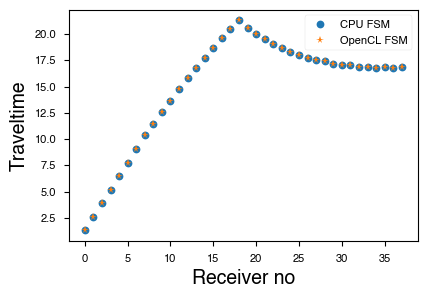

Max absolute difference: 0.000e+00
L2 norm of difference:   0.000e+00


In [6]:
plt.figure(figsize=(4.5,3))
plt.plot(tt_cpu, 'o', label='CPU FSM')
plt.plot(tt_gpu, '*', label='OpenCL FSM')
plt.xlabel('Receiver no', fontsize=14)
plt.ylabel('Traveltime', fontsize=14)
plt.legend()
plt.show()

print('Max absolute difference: {0:.3e}'.format(np.max(np.abs(tt_cpu - tt_gpu))))
print('L2 norm of difference:   {0:.3e}'.format(np.linalg.norm(tt_cpu - tt_gpu)))

In [7]:
print('Compute time\n\n    CPU FSM:    {0:.3f} s\n    OpenCL FSM: {1:.3f} s\n'.format(
    compute_time_cpu, compute_time_gpu))
print('speed-up: {0:.1f}x'.format(compute_time_cpu/compute_time_gpu))

Compute time

    CPU FSM:    0.977 s
    OpenCL FSM: 0.907 s

speed-up: 1.1x


For a grid of this modest size the overhead of transferring data to and from
the GPU may offset the gain from parallel computation, so the OpenCL
implementation really pays off on larger grids.